In [9]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from libs import dataloading, qnn_models, circuits
from libs.helpers import mix_with_white
import numpy as np
import os
import pandas as pd
from cmcrameri import cm
import matplotlib as mpl
from matplotlib.colors import LogNorm
import pickle
import re
import tensorflow as tf
from joblib import Parallel, delayed
import numpy as np
import pickle
import pennylane as qml
plt.style.use('./libs/notebookstyle_aps.mplstyle')

%load_ext autoreload
%autoreload 2

2026-06-30 12:00:42.074254: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-06-30 12:00:42.074313: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-06-30 12:00:42.075442: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-06-30 12:00:43.253919: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


## Plot an overview of the R² values of all models

### quantum models

In [10]:
dfq = pd.read_csv('./QNN_results/QNN_r2.txt', header = 0)

In [11]:
def parse_config(s):
    match = re.match(r"(\d+)qubits_circuit_([a-zA-Z]+)_([a-zA-Z]+)_freq(\d+)enc_(\d+)dec_([a-zA-Z]+)", s)
    if match:
        qubits, enc_angles, angles, n_enc, n_dec,  entanglement = match.groups()
        return int(qubits), int(n_enc), int(n_dec), entanglement, angles, enc_angles
    return None, None, None, None

dfq[['n_qubits', 'n_enc', 'n_dec', 'entanglement','angles','enc_angles']] = dfq['model_name'].apply(
    lambda x: pd.Series(parse_config(x))
)

dfq['nonlocal'] = (dfq.entanglement == 'nonlocal')*1.
dfq['n_params'] = dfq.n_qubits*(dfq.n_enc + dfq.n_dec)*dfq.angles.apply(lambda s: len(s)) + dfq.n_qubits*dfq.n_enc*dfq.enc_angles.apply(lambda s: len(s))

In [12]:
dfqm = dfq.drop(columns = ['key','n_qubits', 'n_enc', 'n_dec', 'entanglement','angles','enc_angles', 'nonlocal']).groupby('model_name').aggregate(['mean','std']).reset_index()
dfqm[['n_qubits', 'n_enc', 'n_dec', 'entanglement','angles','enc_angles']] = dfqm['model_name'].apply(
    lambda x: pd.Series(parse_config(x))
)
dfqm['nonlocal'] = (dfqm.entanglement == 'nonlocal')*1.
dfqm['n_params'] = dfqm.n_qubits*(dfqm.n_enc + dfqm.n_dec)*dfqm.angles.apply(lambda s: len(s)) + dfqm.n_qubits*dfqm.n_enc*dfqm.enc_angles.apply(lambda s: len(s))

In [13]:
dfqm[dfqm['r2_val','mean'] < 0.55]

model_name r2_train_unscaled  \
                                                                 mean   
0       2qubits_circuit_XYZ_XYZ_freq1enc_0dec_local          0.027796   
127   3qubits_circuit_XY_XYZ_freq1enc_0dec_nonlocal          0.010711   
225  4qubits_circuit_XYZ_XYZ_freq1enc_0dec_nonlocal          0.432050   

              r2_val_unscaled            r2_train              r2_val  \
          std            mean       std      mean       std      mean   
0    0.000194        0.027933  0.000198  0.032338  0.000037  0.032711   
127  0.002175        0.010706  0.002305  0.014084  0.001507  0.014264   
225  0.108241        0.432437  0.107931  0.463909  0.113993  0.464957   

              mse_train  ...   mse_val n_params     n_qubits n_enc n_dec  \
          std      mean  ...       std     mean std                        
0    0.000039  0.241780  ...  0.000010       12  12        2     1     0   
127  0.001699  0.246341  ...  0.000425       15  15        3     1     0   
225  0.113858  0.133948  ...  0.028508       24  24        4     1     0   

    entanglement angles enc_angles nonlocal  
                                             
0          local    XYZ        XYZ      0.0  
127     nonlocal    XYZ         XY      1.0  
225     nonlocal    XYZ        XYZ      1.0  

[3 rows x 22 columns]

In [14]:
dfq.n_params.max()

252

### classical models

In [15]:
df = pd.read_csv('./cl_results/clNN_r2.txt', header = None, index_col = None)
df.columns = ['runnr','model_name','r2_train_unscaled', 'r2_val_unscaled', 'r2_train', 'r2_val', 'mse_train', 'mse_val' ]

In [16]:
model_list_all = !ls './cl_models/'
model_list = [s for s in model_list_all if ((s[-2:] == '_1') and ('_' in s[:-2]))]
models = []
n_params = []
for model1 in model_list:
    model = tf.keras.models.load_model('./cl_models/' + model1)
    models += [model]
    n_params += [[model.name, model.count_params()]]

In [20]:
df = df.merge(pd.DataFrame(n_params, columns = ['model_name', 'n_params']))
dfm = df.drop(columns = 'model_name').groupby('n_params').aggregate(['mean','std'])

### QNN height dependent plots

In [24]:
jnp_train_inputs, jnp_val_inputs, jnp_train_outputs, jnp_val_outputs = dataloading.load_data(0, n_samples = 'all')
dfq1 = dfq.rename(columns = {'nonlocal':'nonlocal_flag'}) ### otherwise problems occur due to reserved names

In [11]:
def load_eval(mykey, n_qubits, n_enc, n_dec, local_observable, enc_angles, save_dir = "./QNN_results", MISSING_LOG = "missing_files.txt"):

    mycircuit = circuits.PQCircuit(
        n_enc, n_dec, n_qubits,
        var_angles="XYZ",
        encoding_angles=enc_angles,
        choose_freq=True,
    )

    dev = qml.device("default.qubit", wires=n_qubits)
    model_qnn, no_params, model_name = qnn_models.make_model(
        dev, mycircuit, local_observable
    )

    fname = f"{save_dir}/{model_name}_optparams{mykey}.npz"

    # if file is missing
    if not os.path.exists(fname):
        with open(MISSING_LOG, "a") as f:
            f.write(fname + "\n")
        return np.nan, np.nan

    opt_pars = np.load(fname)["opt_params"]
    jnp_val_hat = model_qnn(opt_pars, jnp_val_inputs)

    return model_name, jnp_val_hat


In [12]:
calculate_data = False # set true to calculate the data for the vertical profiles
def _process(row):
    model_name, jnp_val_hat = load_eval(
        row.key,
        row.n_qubits,
        row.n_enc,
        row.n_dec,
        row.nonlocal_flag,
        row.enc_angles,
    )
    return (row.key, model_name), jnp_val_hat

if calculate_data:
    res_dict = dict(
        Parallel(
            n_jobs=100,
            backend="loky",
            prefer="processes",
            batch_size=10, 
        )(
            delayed(_process)(row)
            for row in dfq1.itertuples(index=False)
        )
    )
    
    with open("./QNN_results/vert_profiles.pkl", "wb") as f:
        pickle.dump(res_dict, f)

In [25]:
with open("./QNN_results/vert_profiles.pkl", "rb") as f:
    res_dict = pickle.load(f)

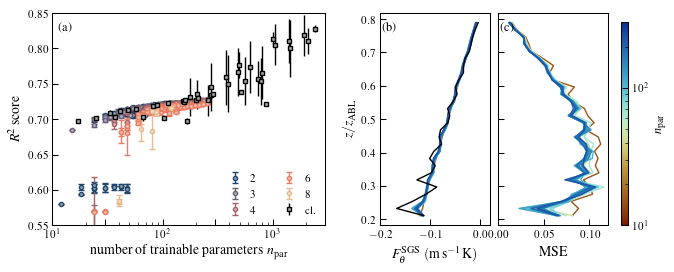

In [27]:
fig = plt.figure(figsize=(6.77, 2.4*1.3))

outer = gridspec.GridSpec(
    1, 2,
    width_ratios=[1.2, 1],
    wspace=0.22
)

ax1 = fig.add_subplot(outer[0])

inner = gridspec.GridSpecFromSubplotSpec(
    1, 2,
    subplot_spec=outer[1],
    wspace=0.08
)

ax2 = fig.add_subplot(inner[0])
ax3 = fig.add_subplot(inner[1], sharey=ax2)
ax3.tick_params(labelleft=False)

for ax, lab in zip([ax1, ax2, ax3], ["(a)", "(b)", "(c)"]):
    ax.text(0.02, 0.96, lab, transform=ax.transAxes,
            va="top", ha="left", fontsize=9)


colours = cm.lipari(np.linspace(0.15,0.85,5))

for i, (grp_key, grp) in enumerate(dfqm.groupby('n_qubits')):
    first = True
    for _, grp2 in grp.groupby(['enc_angles', 'nonlocal']):
        ax1.errorbar(
            grp2.n_params['mean'],
            grp2.r2_val['mean'],
            grp2.r2_val['std'],
            fmt='o',
            markersize=3,
            color=colours[i % len(colours)],
            markerfacecolor=mix_with_white(colours[i % len(colours)], 0.5),
            capsize=2,
            label=str(grp_key) if first else None,
        )
        first = False

ax1.errorbar(
    dfm.index,
    dfm.r2_val['mean'],
    dfm.r2_val['std'],
    fmt='s',
    markersize=3,
    color='k',
    markerfacecolor='darkgrey',
    label='cl.',
)

ax1.set_xscale('log')
current_ticks = ax1.get_xticks()
ax1.set_xticks(list(current_ticks) + [30, 300])
ax1.set_xlim(10, 3e3) #600)
ax1.set_ylim(0.55, 0.85)
ax1.set_xlabel(r"number of trainable parameters $n_{\rm par}$")
ax1.set_ylabel(r"$R^2$ score")

ax1.legend(
    frameon=False,
    fontsize=8,
    loc="lower right",
    handletextpad=0.4,
    ncol = 2
)


dfq3 = dfq[(dfq.r2_val > 0.65)] # select the models on the band with good performance to show height dependence
#bin_edges = np.linspace(0.2, 0.8, 20)
bin_edges = np.linspace(0.2,0.8, 29, endpoint = True)
zs = np.asarray(jnp_val_inputs[:, 2]) / np.pi + 0.5

norm = mpl.colors.Normalize(
    vmin=dfq3["n_params"].min(),
    vmax=dfq3["n_params"].max(),
)


def bin_by_height(zs, y, bin_edges):
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    out = np.full(len(bin_centers), np.nan)
    for i in range(len(bin_centers)):
        m = (zs >= bin_edges[i]) & (zs < bin_edges[i + 1])
        if m.sum() > 1:
            out[i] = np.mean(y[m])
    return bin_centers, out



norm = LogNorm(vmin=10, vmax=300)
sm = mpl.cm.ScalarMappable(norm=norm, cmap=cm.roma)
sm.set_array([])
y_true = np.asarray(jnp_val_outputs)

for j in dfq3.sort_values('n_params').iloc[::200].index:
        key, model = tuple(dfq3[['key', 'model_name']].loc[j])
        color = cm.roma(norm(dfq3.loc[j, 'n_params']))
        y_pred = np.asarray(res_dict[(key, model)])

        zc, yp = bin_by_height(zs, dataloading.unpreprocess_target(y_pred), bin_edges)
        ax2.plot(yp, zc, color=color, lw=1)
    
        zc, mse = bin_by_height(zs, (y_true - y_pred) ** 2, bin_edges)
        ax3.plot(mse, zc, color=color, lw=1)
        
zc, yt = bin_by_height(zs, dataloading.unpreprocess_target(y_true), bin_edges)
ax2.plot(yt, zc, color='k', lw=1)


cax = fig.add_axes([0.92, 0.22, 0.01, 0.65])
cbar = fig.colorbar(sm, cax=cax)
cbar.set_label(r"$n_{\rm par}$", fontsize=9)
cbar.ax.tick_params(labelsize=8)

ax2.set_xlabel(r"$F_{\theta}^{\mathrm{SGS}}\;(\mathrm{m\,s^{-1}\,K})$")
ax2.set_ylabel(r"$z/z_{\mathrm{ABL}}$")
ax2.set_xlim(-0.2, 0.02)

ax3.set_xlabel("MSE")
ax3.set_xlim(0.0, 0.12)

plt.subplots_adjust(
    left=0.08,
    right=0.90,
    bottom=0.22,
    top=0.90
)


fig.align_xlabels()
fig.savefig("./figures/R2scores_three_panel.jpg")
fig.savefig("./figures/R2scores_three_panel.pdf")
fig.show()

In [28]:
df.r2_val.max(), df.n_params.max(), df.r2_val.min()

(0.8376330733299255, 2421, 0.6883213520050049)

In [29]:
dfq.r2_val.max(), dfq.n_params.max(), dfq.r2_val.min()

(0.7293859720230103, 252, 0.0094441175460815)